## Derivative-Constrained PINN — Gibson–Schwartz convenience-yield inversion

Self-contained: the closed-form GS pricer is copied in below (not imported from `gs_wamol`), with an autodiff PDE self-check.

Architecture:
- **Path net** `delta_hat_phi(t)` — latent convenience yield.
- **Drift net** `A_hat_theta(tau)` — `B(tau)` is analytic (closed form); only `A(tau)` is learned.
- **Pricing transform**: `F_hat = S * exp(B(tau) * delta_hat + A_hat)`.
- **Loss** = `e_data` (price MSE) + `e_ode` (ODE residual on `A_hat`) + `e_sde` (OU transition NLL on the path), WamOL-balanced.

In [27]:
import os
import sys
import types
import pickle
import time
from dataclasses import dataclass, asdict
from typing import Callable, Dict, Tuple, Union

import jax
import jax.numpy as jnp
from jax import grad, jacrev, jit, lax, random, vmap
from jax.nn.initializers import glorot_normal, normal, zeros
from jax.flatten_util import ravel_pytree
from jax.tree_util import tree_leaves, tree_map

import optax
import ml_collections
from flax import linen as nn
from flax.training import train_state, orbax_utils
import orbax.checkpoint

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
print("JAX:", jax.__version__, "| x64 enabled:", jax.config.jax_enable_x64,
      "| default dtype:", jnp.ones(1).dtype)


JAX: 0.9.1 | x64 enabled: False | default dtype: float32


### Closed-form Gibson–Schwartz pricer

$$\hat{F}(\tau, S, \delta) = S\exp\!\big[B(\tau)\delta + A(\tau)\big],\qquad B(\tau) = -\frac{1-e^{-\kappa\tau}}{\kappa}$$

`B_coeff` is used directly in the pricing transform below. `A_coeff`/`futures`/`GSParams` are not used in the loss (that would trivially satisfy the PDE) — they only back the self-check at the bottom of this cell.

In [28]:
# Gibson-Schwartz Model 2 closed-form futures pricer. Do not edit these
# coefficients without re-running the self-check below.


@dataclass(frozen=True)
class GSParams:
    """Risk-neutral GS Model 2 params. alpha_Q = alpha_P - sigma2*lambda2/kappa."""
    r: float
    kappa: float
    alpha_Q: float
    sigma1: float
    sigma2: float
    rho: float


def B_coeff(tau, kappa):
    return -(1.0 - jnp.exp(-kappa * tau)) / kappa


def A_coeff(tau, p: GSParams):
    kappa = p.kappa
    s1s2rho = p.sigma1 * p.sigma2 * p.rho
    s2sq = p.sigma2 ** 2

    lin = (p.r - p.alpha_Q + 0.5 * s2sq / kappa ** 2 - s1s2rho / kappa) * tau
    two_kappa = 0.25 * s2sq * (1.0 - jnp.exp(-2.0 * kappa * tau)) / kappa ** 3
    one_kappa = (p.alpha_Q * kappa + s1s2rho - s2sq / kappa) * (1.0 - jnp.exp(-kappa * tau)) / kappa ** 2
    return lin + two_kappa + one_kappa


def log_futures(tau, S, delta, p: GSParams):
    return jnp.log(S) + B_coeff(tau, p.kappa) * delta + A_coeff(tau, p)


def futures(tau, S, delta, p: GSParams):
    return jnp.exp(log_futures(tau, S, delta, p))


# Pickle resolution shim: mc_data.pkl stores GSParams by class path, so
# resolve it to the class defined above instead of the gs_wamol package.
_gs_shim = types.ModuleType("gs_wamol.physics.gibson_schwartz")
_gs_shim.GSParams = GSParams
sys.modules.setdefault("gs_wamol", types.ModuleType("gs_wamol"))
sys.modules.setdefault("gs_wamol.physics", types.ModuleType("gs_wamol.physics"))
sys.modules["gs_wamol.physics.gibson_schwartz"] = _gs_shim


def _gs_selfcheck():
    """Autodiff check that the ported closed form still solves the pricing PDE."""
    p = GSParams(r=0.05, kappa=1.876, alpha_Q=0.0779, sigma1=0.393, sigma2=0.527, rho=0.766)

    def F(tau, S, delta):
        return futures(tau, S, delta, p)

    def residual(tau, S, delta):
        F_tau = grad(F, 0)(tau, S, delta)
        F_S = grad(F, 1)(tau, S, delta)
        F_SS = grad(grad(F, 1), 1)(tau, S, delta)
        F_d = grad(F, 2)(tau, S, delta)
        F_dd = grad(grad(F, 2), 2)(tau, S, delta)
        F_Sd = grad(grad(F, 1), 2)(tau, S, delta)
        return (F_tau
                - (p.r - delta) * S * F_S
                - p.kappa * (p.alpha_Q - delta) * F_d
                - 0.5 * p.sigma1 ** 2 * S ** 2 * F_SS
                - p.rho * p.sigma1 * p.sigma2 * S * F_Sd
                - 0.5 * p.sigma2 ** 2 * F_dd)

    k1, k2, k3 = random.split(random.PRNGKey(0), 3)
    tau = random.uniform(k1, (256,), minval=0.05, maxval=2.0)
    S = random.uniform(k2, (256,), minval=30.0, maxval=170.0)
    d = random.uniform(k3, (256,), minval=-1.0, maxval=1.5)

    rel_pde = jnp.max(jnp.abs(vmap(residual)(tau, S, d) / vmap(F)(tau, S, d)))
    rel_ic = jnp.max(jnp.abs(vmap(lambda S_, d_: F(0.0, S_, d_))(S, d) / S - 1.0))

    tol = 1e-4 if jnp.ones(1).dtype == jnp.float32 else 1e-10
    assert rel_pde < tol, f"ported A/B break the GS PDE: rel residual {rel_pde:.3e}"
    assert rel_ic < tol, f"ported A/B break F(0,S,delta)=S: rel error {rel_ic:.3e}"
    print(f"GS pricer self-check OK  |  rel PDE residual {rel_pde:.2e}, rel IC error {rel_ic:.2e}")


_gs_selfcheck()

GS pricer self-check OK  |  rel PDE residual 2.76e-07, rel IC error 2.98e-07


### Network architecture

Generic `MLP` with optional weight-factorization reparameterisation on `Dense`. Two instances are built below: the drift net `A_hat_theta(tau)` and the path net `delta_hat_phi(t)`.

In [29]:
activation_fn = {
    "tanh": jnp.tanh,
    "sin": jnp.sin,
}


def _get_activation(name):
    if name in activation_fn:
        return activation_fn[name]
    raise NotImplementedError(f"Activation {name} not in dictionary: {activation_fn.keys()}")


def _weight_fact(init_fn, mean, stddev):
    def init(key, shape):
        key1, key2 = random.split(key)
        w = init_fn(key1, shape)
        g = mean + normal(stddev)(key2, (shape[-1],))
        g = jnp.exp(g)
        v = w / g
        return g, v
    return init


class Dense(nn.Module):
    features: int
    kernel_init: Callable = glorot_normal()
    bias_init: Callable = zeros
    reparam: Union[None, Dict] = None

    @nn.compact
    def __call__(self, x):
        if self.reparam is None:
            kernel = self.param(
                "kernel", self.kernel_init, (x.shape[-1], self.features)
            )
        elif self.reparam["type"] == "weight_fact":
            g, v = self.param(
                "kernel",
                _weight_fact(
                    self.kernel_init,
                    mean=self.reparam["mean"],
                    stddev=self.reparam["stddev"],
                ),
                (x.shape[-1], self.features),
            )
            kernel = g * v
        bias = self.param("bias", self.bias_init, (self.features,))
        y = jnp.dot(x, kernel) + bias
        return y


class MLP(nn.Module):
    hidden_dim: Tuple[int] = (32, 16)
    out_dim: int = 1
    activation: str = "tanh"
    reparam: Union[None, Dict] = None

    def setup(self):
        self.activation_fn = _get_activation(self.activation)

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.hidden_dim)):
            x = Dense(features=self.hidden_dim[i], reparam=self.reparam)(x)
            x = self.activation_fn(x)
        x = Dense(features=self.out_dim, reparam=self.reparam)(x)
        # original: x = nn.softplus(x) -- removed, delta_hat is unconstrained in sign
        return x

In [30]:
# --- Two networks (per the attached architecture diagram) ------------------
#   A_hat_theta : tau -> R      the DRIFT term         (in_dim 1)  <-- NEW, replaces the 3-D surface net
#   delta_hat_phi : t -> R      the latent PATH         (in_dim 1)  <-- unchanged
#
# What changed vs. the old (S, delta, tau) -> R+ surface net: B(tau) is now taken
# straight from the analytic closed form (B_coeff, already ported above) instead
# of being folded into a learned surface. Only the A(tau) piece is learned, so
# the drift net only ever needs tau as input -- there is no more S/delta
# dependence to differentiate through, which is why the PDE residual collapses
# to a 1-D ODE residual in error() below (see the diagram's L_ODE box).
#
# delta_hat_phi is UNCHANGED: still t alone, still not shown S, for the same
# reason as before -- the S-delta dependence is carried by the pricing
# transform + rho, not smuggled into the latent-path network.


def build_nets(config):
    """Return (drift_ann, path_ann). drift_ann replaces the old surface_ann."""
    reparam = None
    if config.ann_reparam:
        reparam = ml_collections.ConfigDict({"type": "weight_fact", "mean": 0.5, "stddev": 0.1})

    # NEW: drift_ann takes tau alone (in_dim 1), not (S, delta, tau) (in_dim 3).
    drift_ann = MLP(hidden_dim=config.drift_hidden_dim,
                    out_dim=1,
                    activation=config.ann_activation_str,
                    reparam=reparam)
    path_ann = MLP(hidden_dim=config.path_hidden_dim,
                   out_dim=1,
                   activation=config.ann_activation_str,
                   reparam=reparam)
    return drift_ann, path_ann


def make_fns(drift_ann, path_ann, params):
    """Bind params into the callables the objective needs.

    NEW pricing transform (per the diagram):

        F_hat(S, delta, tau) = S * exp(B(tau) * delta + A_hat_theta(tau))

    replacing the old S * exp(tau * N_theta(S, delta, tau)). B(tau) is the
    ANALYTIC closed form (B_coeff, using kappa from p_Q) -- not learned. A_hat
    is the only learned piece of the affine exponent, output by the new drift
    net.

    Hard-enforced boundary condition, carried over from the old eq. 47 trick
    since the diagram doesn't spell one out but the requirement (F_hat(0, S) = S)
    is unchanged: A(0) = 0 in the analytic closed form (verified by the
    self-check above), so A_hat is parameterised as tau * N_theta(tau), which
    gives A_hat(0) = 0 identically -- this keeps the boundary condition free
    instead of something L_ODE has to learn on its own.
    """
    def A_hat_fn(tau):
        return tau * drift_ann.apply(params["drift"], normalize_tau(tau))[0]   # NEW

    def log_F_hat_fn(S, delta, tau):
        return jnp.log(S) + B_coeff(tau, p_Q.kappa) * delta + A_hat_fn(tau)    # NEW pricing transform

    def F_hat_fn(S, delta, tau):
        return jnp.exp(log_F_hat_fn(S, delta, tau))

    def delta_hat_fn(t):
        return path_ann.apply(params["path"], normalize_time(t))[0]

    return F_hat_fn, delta_hat_fn, A_hat_fn


def init_nets(config, key):
    """Joint parameter pytree -- one TrainState covers both nets, so a single
    apply_gradients step updates theta and phi together (trained jointly)."""
    drift_ann, path_ann = build_nets(config)
    k_s, k_p = random.split(key, 2)
    params = {
        "drift": drift_ann.init(k_s, jnp.ones((1,))),   # NEW: in_dim 1, was 3
        "path": path_ann.init(k_p, jnp.ones((1,))),
    }
    return drift_ann, path_ann, params

### Optimiser

Core code inherited from https://github.com/khoshisashi/AC-PINNs/blob/main/AC_PINNs_IVS_calibration.ipynb for the original SABR / Dupire-local-vol problem by Khoshisashi et al. 2023. in his ACPINN repo.

In [31]:
beta1 = 0.9
beta2 = 0.999
adam_eps = 1e-8
learning_rate = 1e-3
decay_rate = 0.9
decay_steps = 2000

lr = optax.exponential_decay(
        init_value=learning_rate,
        transition_steps=decay_steps,
        decay_rate=decay_rate,
    )
tx = optax.adam(
    learning_rate=lr, b1=beta1, b2=beta2, eps=adam_eps
)

### Input Data

Monte Carlo simulated data generated by `monte_carlo.ipynb` and saved to `data/gs_mc_data.npz`.

Input data is a 2D array of `(t, S)` pairs, and the corresponding observed forward prices `F_obs` at those points. The network will learn to predict the convenience yield `delta_hat(t, S)` that best fits the observed forward prices under the Gibson-Schwartz model.

In [32]:
def get_data(path_id=0, path="../data/input/synthetic/mc_data.pkl"):

    with open(path, "rb") as f:
        mc_data = pickle.load(f)

    taus = mc_data["taus"]                             
    t_train = mc_data["t_grid"]                          
    S_train = mc_data["S"][path_id]                      
    log_F_obs_train = mc_data["log_F_obs"][path_id]

    # EVAL TARGET ONLY -- never fed to the network or error().
    delta_true = mc_data["delta_true"][path_id]           

    # Rebuild on the notebook's own GSParams rather than trusting whatever class
    # the pickle resolved to. The shim above normally makes these identical; this
    # makes the notebook survive a pkl written by some other GSParams definition,
    # and fails loudly (TypeError on unexpected fields) instead of silently
    # carrying a stale field set into the pricing PDE.
    p_Q = GSParams(**asdict(mc_data["params_Q"]))
    kappa_P = mc_data["params_P"]["kappa"]                 
    alpha_P = mc_data["params_P"]["alpha_P"]               
    sigma2_P = mc_data["params_P"]["sigma2"]               

    return t_train, S_train, taus, log_F_obs_train, delta_true, p_Q, kappa_P, alpha_P, sigma2_P


In [33]:
# --- Bind the panel and the globals the objective closes over --------------
(t_train, S_train, taus, log_F_obs_train,
 delta_true, p_Q, kappa_P, alpha_P, sigma2_P) = get_data(path_id=0)

# delta_true is deliberately NOT in `data`: it is the evaluation target and must
# never reach a loss term (CLAUDE.md S6.3 -- the true delta path is sacred).
data = (t_train, S_train, log_F_obs_train)


# --- Input normalisation ---------------------------------------------------
# Raw inputs span t in [0, 10], tau in [0.08, 2]. tanh saturates outside
# roughly [-3, 3], so every network input is rescaled to about unit spread.
#
#   tau -> tau / TAU_SCALE     -- NEW: the drift net's only input, was folded
#                                 into normalize_surface before
#   t   -> t / T_SCALE         -- unchanged
#
# NEW: LOG_S_MEAN/LOG_S_STD/DELTA_SCALE and normalize_surface are gone -- S and
# delta are no longer network inputs (B(tau) is analytic, A_hat depends on tau
# alone), so there is nothing left to normalise them for.
T_SCALE = float(t_train[-1])
TAU_SCALE = float(taus.max())


def normalize_tau(tau):
    """Physical tau -> drift-network input. Shape (1,): the drift net is 1-D."""
    return jnp.atleast_1d(tau / TAU_SCALE)                                     # NEW


def normalize_time(t):
    """Physical t -> path-network input. Shape (1,): the path net is 1-D (S6)."""
    return jnp.atleast_1d(t / T_SCALE)


# --- Collocation mesh for L_ODE ---------------------------------------------
# NEW: collapses to a 1-D mesh over tau alone. The old (S, delta, tau) mesh
# existed because the PDE residual needed the full state space (S, delta
# independent of any path); now that B(tau) is analytic and only A_hat(tau) is
# learned, the ODE residual (see error() below) only ever needs tau.
N_COLLOCATION = 4096

_key_mesh = random.PRNGKey(0)
tau_mesh = random.uniform(_key_mesh, (N_COLLOCATION,), minval=0.0, maxval=float(taus.max()))
mesh = tau_mesh                                                                 # NEW: was (S_mesh, delta_mesh, tau_mesh)

print("t_train        ", t_train.shape, f"[{float(t_train.min()):.2f}, {float(t_train.max()):.2f}]")
print("S_train        ", S_train.shape, f"[{float(S_train.min()):.2f}, {float(S_train.max()):.2f}]")
print("taus           ", taus.shape, f"[{float(taus.min()):.3f}, {float(taus.max()):.3f}]")
print("log_F_obs_train", log_F_obs_train.shape, "(dates x maturities)")
print("delta_true     ", delta_true.shape, "HELD OUT -- evaluation only")
print("collocation    ", tau_mesh.shape, "points over tau")


t_train         (1001,) [0.00, 10.00]
S_train         (1001,) [35.89, 165.12]
taus            (12,) [0.083, 1.000]
log_F_obs_train (1001, 12) (dates x maturities)
delta_true      (1001,) HELD OUT -- evaluation only
collocation     (4096,) points over tau


### Loss terms — `error()`

Rewritten to match the attached architecture diagram (drift net + analytic B(tau) + three WamOL-balanced loss channels), replacing the earlier terms from `docs/mathematical_derivations-5.pdf`.

- `e_data` = the diagram's $\hat{\mathcal{L}}_{\text{data}}$ — data misfit in log-price space (was `e_acc`)
- `e_ode` = the diagram's $\hat{\mathcal{L}}_{\text{ODE}}$ — ODE residual on $\hat{A}(\tau)$ (replaces the old 3-D PDE residual `e_pde`)
- `e_sde` = the diagram's $\hat{\mathcal{L}}_{\text{SDE}}$ — OU transition-density residual on the recovered path (new)
- The old inequality terms (`e_arb_cac`, `e_arb_rcac`, `e_delta_floor`) and $\mathcal{L}_b$ are **removed** — not part of this architecture

In [34]:
# NEW: STORAGE_COST_U / DELTA_MAX / DELTA_MIN and the arbitrage-bound constants
# are gone -- the cash-and-carry / reverse-cash-and-carry / delta-floor
# inequality terms they fed are not part of this architecture (see the loss
# terms markdown above). If reintroduced later, restore them as an additional
# channel in error()/loss_fn_lb rather than folding them back in here.


def error(fns, data, mesh):
    """Loss residuals, per the attached architecture diagram.

    fns  : (F_hat_fn, delta_hat_fn, A_hat_fn) from make_fns
    data : (t_train, S_train, log_F_obs_train)  -- the DATA MANIFOLD
    mesh : tau_mesh                              -- the COLLOCATION MESH (1-D, tau only)  <-- NEW, was (S_mesh, delta_mesh, tau_mesh)

    Returns (err, metrics), same contract as before.
    """
    F_hat_fn, delta_hat_fn, A_hat_fn = fns
    t_train, S_train, log_F_obs_train = data
    tau_mesh = mesh

    # Latent path at observation times. Input is t alone (S6 remark 1).
    delta_hat = vmap(delta_hat_fn)(t_train)                          # (n,)

    # --- e_data  (the diagram's L_data, was e_acc) --------------------------
    # Priced through the pricing transform F_hat = S * exp(B(tau) delta + A_hat)
    # at the inferred state (S_i, delta_hat_phi(t_i), tau_i). B(tau) is analytic
    # (B_coeff, ported above); A_hat(tau) is the learned drift-net output.
    # delta_hat enters via B(tau) * delta_hat, the sole channel by which
    # observations discipline the path (unchanged from before, S9).
    def log_F_hat_fn(S, delta, tau):
        return jnp.log(S) + B_coeff(tau, p_Q.kappa) * delta + A_hat_fn(tau)

    log_F_hat = vmap(
        lambda S, d: vmap(lambda tau: log_F_hat_fn(S, d, tau))(taus)
    )(S_train, delta_hat)                                            # (n, K)
    e_data = (log_F_hat - log_F_obs_train) ** 2                       # (n, K)

    # --- e_ode  (the diagram's L_ODE, replaces e_pde) -----------------------
    # NEW: dA_hat/dtau - (r + (kappa alpha_Q + rho sigma1 sigma2) B + 0.5 sigma2^2 B^2).
    # This IS the old PDE residual (S10, eq. 44-45), specialised to the case
    # where B(tau) is the exact analytic solution and only A(tau) is learned --
    # the S and delta partials in the old residual cancel out identically once
    # B is exact, leaving only an ODE in tau. No more S/delta collocation mesh
    # is needed, only a tau mesh, and there is no more "delta as an independent
    # coordinate" subtlety to worry about.
    def ode_residual(tau):
        A_tau = grad(A_hat_fn)(tau)
        B = B_coeff(tau, p_Q.kappa)
        rhs = (p_Q.r
               + (p_Q.kappa * p_Q.alpha_Q + p_Q.rho * p_Q.sigma1 * p_Q.sigma2) * B
               + 0.5 * p_Q.sigma2 ** 2 * B ** 2)
        return A_tau - rhs

    e_ode = vmap(ode_residual)(tau_mesh) ** 2                         # (N_f,)

    # --- e_sde  (the diagram's L_SDE, brand new) ----------------------------
    # -log p(delta_hat_{i+1} | delta_hat_i; psi), the discrete-time OU
    # transition density under the PHYSICAL measure -- uses kappa_P, alpha_P,
    # sigma2_P (loaded by get_data but unused until now), NOT p_Q.alpha_Q
    # (CLAUDE.md S2: physical params simulate, risk-neutral params price; never
    # conflate alpha_P/alpha_Q).
    # This is what disciplines the recovered path's DYNAMICS, not just its fit
    # to prices -- the earlier abandoned "OU drift-consistency" term mentioned
    # in the intro cell was reaching for exactly this, before the network I/O
    # and pricing transform had been pinned down.
    dt = jnp.diff(t_train)                                            # (n-1,)

    def sde_nll(delta_i, delta_ip1, dt_i):
        mean = alpha_P + (delta_i - alpha_P) * jnp.exp(-kappa_P * dt_i)
        var = (sigma2_P ** 2 / (2.0 * kappa_P)) * (1.0 - jnp.exp(-2.0 * kappa_P * dt_i))
        return 0.5 * jnp.log(2.0 * jnp.pi * var) + 0.5 * (delta_ip1 - mean) ** 2 / var

    e_sde = vmap(sde_nll)(delta_hat[:-1], delta_hat[1:], dt)          # (n-1,)

    err = {
        "e_data": e_data,
        "e_ode": e_ode,
        "e_sde": e_sde,
    }
    metrics = {k: jnp.mean(v) for k, v in err.items()}
    return err, metrics


In [35]:
def adj(loss, lw):
    return lw * jnp.mean(loss)


def make_loss_lb(components):
    def loss_fn(fns, data, mesh, l_ws):
        err, metrics = error(fns, data, mesh)
        loss = {k: adj(err[k], l_ws[k]) for k in components}
        return loss, metrics
    return loss_fn


def make_loss_fn(components):
    def loss_fn(fns, data, mesh, l_ws):
        loss, metrics = loss_fn_lb[components](fns, data, mesh, l_ws)
        return sum(loss.values()), metrics
    return loss_fn


# MLP:    data fit only -- ablation. The drift net is unconstrained by physics,
#         so this asks whether fitting the panel alone already pins delta.
# PINN:   data fit + ODE residual on the tau mesh.
# DCPINN: PINN + the OU transition-density term -- the full architecture,
#         with WamOL gradient-norm balancing across the three components.
loss_fn_lb = {
    "MLP":    make_loss_lb(["e_data"]),
    "PINN":   make_loss_lb(["e_data", "e_ode"]),
    "DCPINN": make_loss_lb(["e_data", "e_ode", "e_sde"]),
}

loss_fn = {k: make_loss_fn(k) for k in loss_fn_lb}

### Calibration

Training loop with WamOL gradient-norm balancing across the composite loss's components (`l_ws` for `e_data`/`e_ode`/`e_sde`), plus checkpointing. The per-point ("piecewise") self-adaptive weight optimizer from the original AC-PINN code (`params_sa`, SGD ascent) is removed -- only the component-level balancing is kept.

In [36]:
def flatten_pytree(pytree):
    return ravel_pytree(pytree)[0]

init_l_ws = {
    "MLP": {'e_data': 1.},
    "PINN": {'e_data': 1., 'e_ode': 1.},
    "DCPINN": {'e_data': 1., 'e_ode': 1., 'e_sde': 1.},
}


def calibration(config, data, mesh):
    ofunc = loss_fn[config.loss_str]
    l_ws = dict(init_l_ws[config.loss_str])

    key = random.PRNGKey(config.seed)
    key, key_init = random.split(key, 2)

    # One TrainState over the joint pytree {"drift": theta, "path": phi} --
    # a single apply_gradients step updates both nets from the one composite objective.
    drift_ann, path_ann, params_init = init_nets(config, key_init)
    state = train_state.TrainState.create(apply_fn=None, params=params_init, tx=tx)

    @jit
    def train_step(state, data, mesh, l_ws):
        def loss_fn_(params):
            fns = make_fns(drift_ann, path_ann, params)
            return ofunc(fns, data, mesh, l_ws)

        (loss, metric), grads = jax.value_and_grad(loss_fn_, has_aux=True)(state.params)
        state = state.apply_gradients(grads=grads)
        return state, loss, metric

    hist_loss = []
    momentum = config.loss_balancing_momentum
    start_time = time.time()

    @jit
    def update_loss_weights(state, data, mesh, l_ws):
        def loss_fn_(params):
            fns = make_fns(drift_ann, path_ann, params)
            return loss_fn_lb[config.loss_str](fns, data, mesh, l_ws)[0]
        grads = jacrev(loss_fn_)(state.params)

        # NOTE (S12.2, eq. 55-56): this takes the mean |grad| over the FULL
        # parameter vector psi = (theta, phi), not each component's own support
        # (psi_ode = theta, psi_sde = phi) as the paper specifies. Left as-is;
        # tracked in pinn_rewrite_todo.md.
        grad_norm_dict = {k: jnp.abs(flatten_pytree(v)).mean() for k, v in grads.items()}
        sum_grad_norm = jnp.sum(jnp.stack(tree_leaves(grad_norm_dict)))
        w = tree_map(lambda x: jnp.where(x == 0., 1., sum_grad_norm / x), grad_norm_dict)

        weights = tree_map(lambda old_w, new_w: old_w * momentum + (1 - momentum) * new_w, l_ws, w)
        return lax.stop_gradient(weights)

    # Training loop
    print(f"{config.loss_str} calibration------>")
    # config.balancing gates the WamOL component-weight balancing. Only DCPINN
    # carries all three loss channels it was built for, so it is the only
    # variant that ever runs the balancer. Setting it False runs DCPINN with
    # fixed lambda=1 -- the control that isolates whether the balancer, not the
    # extra loss channels, drives any path collapse.
    use_balancing = config.get("balancing", True) and config.loss_str == "DCPINN"
    for epoch in range(config.num_epochs):

        if use_balancing and epoch % 100 == 0:
            l_ws = update_loss_weights(state, data, mesh, l_ws)

        state, loss, metric = train_step(state, data, mesh, l_ws)

        if (epoch % 1000) == 0:
            print(f"Epoch {epoch}: loss = {loss:.6f}", end="\r")
            hist_loss.append((epoch, float(loss), metric))

    comp_time = time.time() - start_time
    print(f"------> completed in {comp_time:.2f} seconds")

    # Save checkpoint
    CKPT_DIR = os.path.abspath(f'../data/output/checkpoints/{run_tag(config)}')
    ckpt = {'params': state.params, 'ls': l_ws}
    orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
    save_args = orbax_utils.save_args_from_target(ckpt)
    orbax_checkpointer.save(CKPT_DIR, ckpt, force=True, save_args=save_args)

    # Return the bound callables, not a single `fn` -- downstream code needs the
    # drift and the path separately.
    return make_fns(drift_ann, path_ann, state.params), hist_loss


def run_tag(config):
    """File-safe name distinguishing DCPINN with balancing on vs off."""
    if config.loss_str == "DCPINN" and not config.get("balancing", True):
        return "DCPINN_nobal"
    return config.loss_str


def run_experiment(config, data, mesh):
    fns, hist_loss = calibration(config, data, mesh)

    results = {'config': config, 'history': hist_loss}
    with open(f'../data/output/results/results_{run_tag(config)}.pkl', 'wb') as f:
        pickle.dump(results, f)

    return fns

### Run

`ann_in_dim=2` (`t, S`), `ann_out_dim=1` (`delta_hat`) — matches eq. (32)'s `delta_hat(t_i, S_i)`. `pts_num` is dropped: the original resampled a fixed-size training batch from its synthetic distribution each run; here the whole path is used as one batch, so there's no equivalent knob (add batching/subsampling here yourself if `n` gets large enough to matter).

`num_epochs=3000` below is a smoke-test setting to prove the wiring runs end to end — not a converged model, and DCPINN in particular (3 loss channels, gradient-norm rebalancing every 100 epochs) will need more.

In [ ]:
# Two nets now, so there is no single `ann_in_dim`: the drift net is 1-D (tau)
# and the path net is 1-D (t). `drift_hidden_dim` replaces the old
# `surface_hidden_dim` now that the learned piece is only A_hat(tau), not the
# full (S, delta, tau) surface.                                                 # NEW
config_MLP = ml_collections.ConfigDict({
    "loss_str": "MLP",
    "num_epochs": 30000,
    "drift_hidden_dim": (64, 64, 64, 64),
    "path_hidden_dim": (32, 32, 32),
    "ann_activation_str": "tanh",
    "loss_balancing_momentum": 0.5,
    "seed": 42,
    "ann_reparam": True,
    "balancing": True,     # WamOL whack-a-mole on by default (DCPINN only)
})

config_PINN = ml_collections.ConfigDict(config_MLP.to_dict())
config_PINN.loss_str = "PINN"

config_DCPINN = ml_collections.ConfigDict(config_PINN.to_dict())
config_DCPINN.loss_str = "DCPINN"

# CONTROL: DCPINN with the WamOL balancer OFF. Same loss terms, same seed,
# fixed lambda=1 / m=1. If this recovers the path like PINN does while the
# balanced DCPINN collapses, the balancer -- not the extra loss channels -- is
# the cause.
config_DCPINN_nobal = ml_collections.ConfigDict(config_DCPINN.to_dict())
config_DCPINN_nobal.balancing = False

fns_MLP = run_experiment(config_MLP, data, mesh)
fns_PINN = run_experiment(config_PINN, data, mesh)
fns_DCPINN = run_experiment(config_DCPINN, data, mesh)

fns_DCPINN_nobal = run_experiment(config_DCPINN_nobal, data, mesh)

MLP calibration------>
------> completed in 58.23 seconds
PINN calibration------>
------> completed in 138.91 seconds
DCPINN calibration------>
------> completed in 173.71 seconds
DCPINN calibration------>


In [ ]:
# compute summary metrics for each model
for fns, config in zip([fns_MLP, fns_PINN, fns_DCPINN, fns_DCPINN_nobal],
                       [config_MLP, config_PINN, config_DCPINN, config_DCPINN_nobal]):
    err, metrics = error(fns, data, mesh)
    print(f"Metrics for {run_tag(config)}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.6e}")


Metrics for MLP:
  e_data: 1.529105e-03
  e_ode: 2.858313e-04
  e_sde: -2.026295e+00
Metrics for PINN:
  e_data: 1.524571e-03
  e_ode: 9.204403e-06
  e_sde: -2.026382e+00
Metrics for DCPINN:
  e_data: 5.611518e-03
  e_ode: 7.907776e-06
  e_sde: -2.033283e+00
Metrics for DCPINN_nobal:
  e_data: 3.655902e-03
  e_ode: 8.178124e-06
  e_sde: -2.032664e+00


### Visualization

`plot_training_history` is ported verbatim — it's loss-component-agnostic (reads whatever metric keys are in the pickled history), so it works unmodified for MLP/PINN/DCPINN alike. Dropped entirely: `plot_volatility_surface`, `plot_arbitrage_heatmaps`, `compare_with_sabr` — all keyed on a `(K,T)` grid that doesn't exist here.

`plot_delta_recovery` is new — the GS analogue of `compare_with_sabr`'s "learned vs. true" comparison. `delta_true` is used here and only here, exactly as CLAUDE.md requires ("the true delta_t path is sacred... never an input to the inversion") — it's a post-hoc scoring plot, not something the network ever sees.


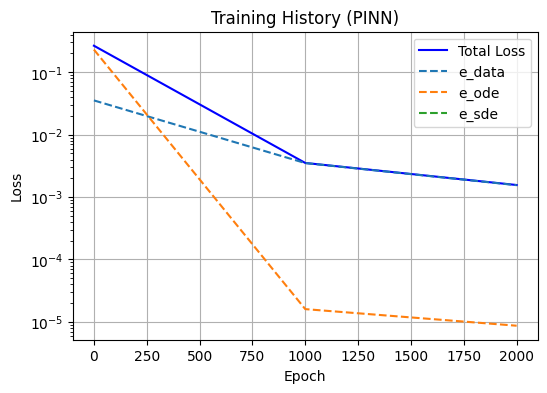

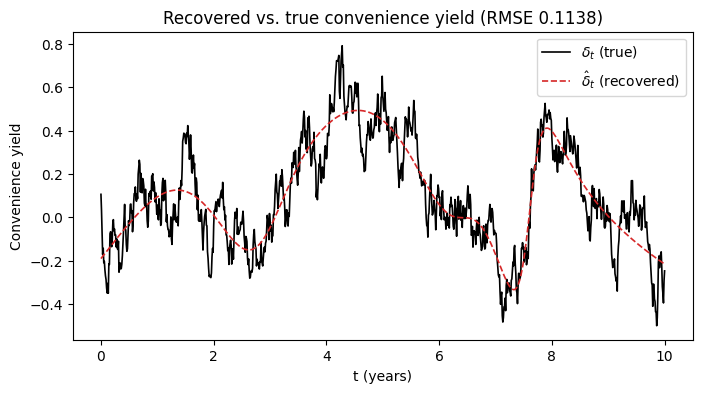

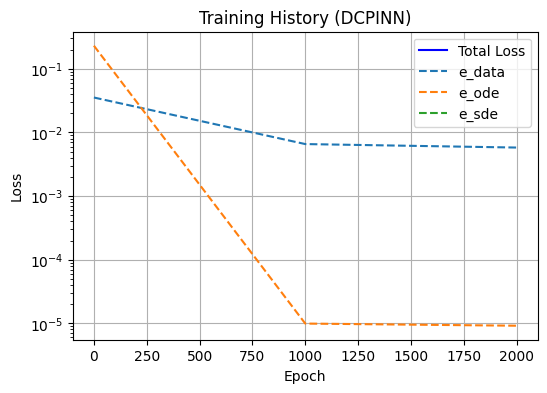

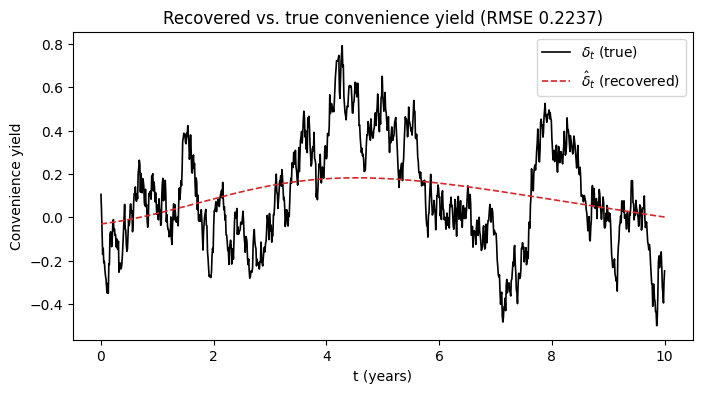

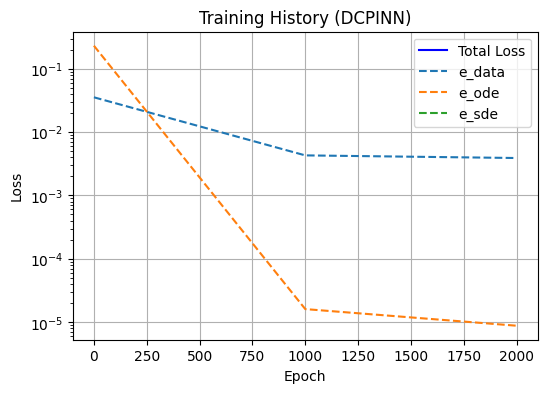

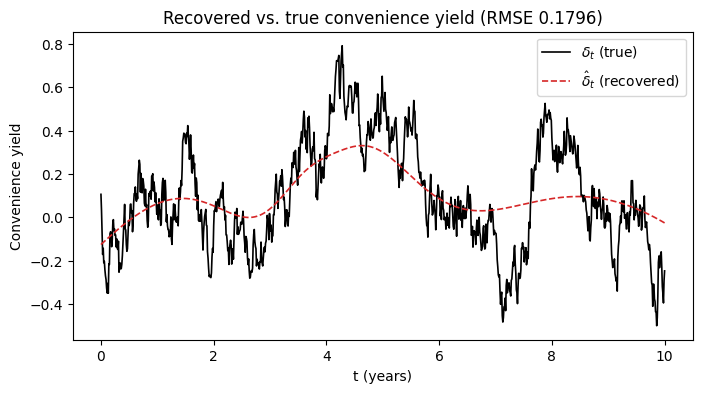

In [ ]:
def plot_training_history(history_path, save_path=None):
    """Plot training loss history"""
    with open(history_path, 'rb') as f:
        results = pickle.load(f)
    history = results['history']

    epochs, losses, metrics = zip(*history)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(epochs, losses, 'b-', label='Total Loss')

    for key in metrics[0].keys():
        metric_values = [m[key] for m in metrics]
        ax.plot(epochs, metric_values, '--', label=key)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')
    ax.grid(True)
    ax.legend()
    plt.title(f"Training History ({results['config'].loss_str})")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_delta_recovery(fns, t, delta_true, save_path=None):
    """Recovered delta_hat_phi(t) vs. the true (eval-only) delta_t path.

    The path net takes t alone (S6 remark 1), so S is not an argument.
    """
    _, delta_hat_fn, _ = fns
    delta_hat = vmap(delta_hat_fn)(t)

    rmse = float(jnp.sqrt(jnp.mean((delta_hat - delta_true) ** 2)))

    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(t, delta_true, color='black', lw=1.2, label=r'$\delta_t$ (true)')
    ax.plot(t, delta_hat, color='tab:red', lw=1.2, ls='--', label=r'$\hat{\delta}_t$ (recovered)')
    # NEW: no more DELTA_MIN floor line -- the convenience-yield floor
    # constraint was part of the old ACPINN inequality terms, which are gone
    # from this architecture (replaced by the OU transition-density term).
    ax.set_xlabel('t (years)')
    ax.set_ylabel('Convenience yield')
    ax.legend()
    ax.set_title(f'Recovered vs. true convenience yield (RMSE {rmse:.4f})')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


os.makedirs('figures', exist_ok=True)

plot_training_history('../data/output/results/results_PINN.pkl', '../figures/pinn/training_history_PINN.png')
plot_delta_recovery(fns_PINN, t_train, delta_true, '../figures/pinn/delta_recovery_PINN.png')

plot_training_history('../data/output/results/results_DCPINN.pkl', '../figures/pinn/training_history_DCPINN.png')
plot_delta_recovery(fns_DCPINN, t_train, delta_true, '../figures/pinn/delta_recovery_DCPINN.png')

# Control: DCPINN, balancer off.
plot_training_history('../data/output/results/results_DCPINN_nobal.pkl', '../figures/pinn/training_history_DCPINN_nobal.png')
plot_delta_recovery(fns_DCPINN_nobal, t_train, delta_true, '../figures/pinn/delta_recovery_DCPINN_nobal.png')
